# Phase 3: Explainable AI (XAI) and Visualization

In this notebook, we aim to "open the black box" of our protein classification models. We will use:
1. **UMAP:** To visualize the 1024-dimensional ProtBERT embeddings in a 2D space.
2. **SHAP:** To identify which features (dimensions) of the embedding space are most influential in predicting whether a protein is an enzyme.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import umap
import shap
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import os

# Set seed for reproducibility
np.random.seed(42)

# Load data
X = np.load('../data/processed/X_embeddings.npy')
y = np.load('../data/processed/y_labels.npy')

# Split data (required for model training in later cells)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Loaded embeddings shape: {X.shape}")
print(f"Training set shape: {X_train.shape}")

e:\Colleage Files\New Mansora University\Level 3\Semester 2\Structural Bioinformatics\Labs\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded embeddings shape: (2000, 1024)
Training set shape: (1600, 1024)


## 1. Dimensionality Reduction with UMAP

UMAP (Uniform Manifold Approximation and Projection) is a powerful tool for visualizing high-dimensional data. We will map the 1024D embeddings to 2D to see how well the classes (Enzyme vs. Non-Enzyme) are separated.

Running UMAP dimensionality reduction...


e:\Colleage Files\New Mansora University\Level 3\Semester 2\Structural Bioinformatics\Labs\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


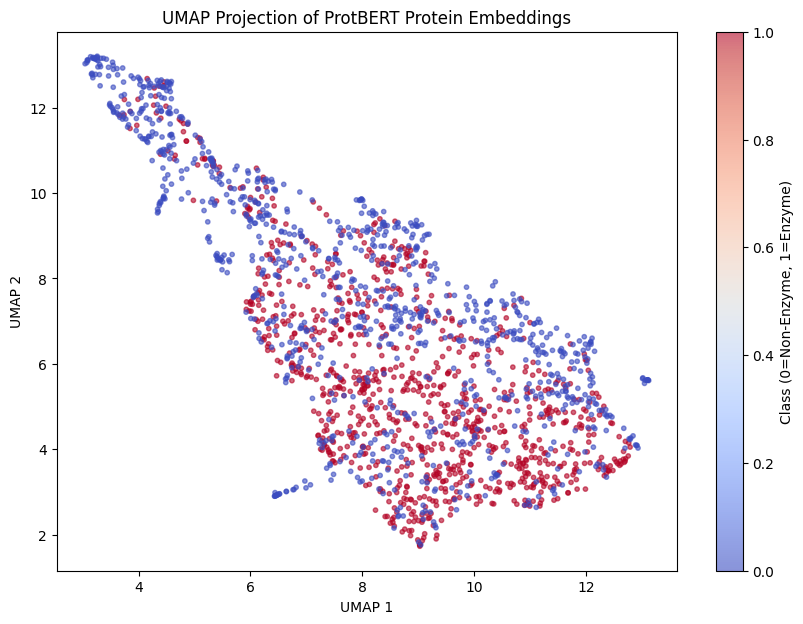

In [2]:
print("Running UMAP dimensionality reduction...")
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
embedding_2d = reducer.fit_transform(X)

# Plotting
plt.figure(figsize=(10, 7))
scatter = plt.scatter(embedding_2d[:, 0], embedding_2d[:, 1], c=y, cmap='coolwarm', s=10, alpha=0.6)
plt.colorbar(scatter, label='Class (0=Non-Enzyme, 1=Enzyme)')
plt.title('UMAP Projection of ProtBERT Protein Embeddings')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
os.makedirs('../results', exist_ok=True)
plt.savefig('../results/umap_projection.png', dpi=300)
plt.show()

## 2. Global Explainability with SHAP

We will use the **Random Forest** model (which was previously trained) to compute SHAP values. Since ProtBERT embeddings are abstract, SHAP value summary plots will show us how much individual dimensions contribute to the "Enzyme-ness" of a protein.

Computing SHAP values (this may take a moment)...


C:\Users\karim\AppData\Local\Temp\ipykernel_26028\547240689.py:22: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, X, plot_type="bar", max_display=20, show=False)


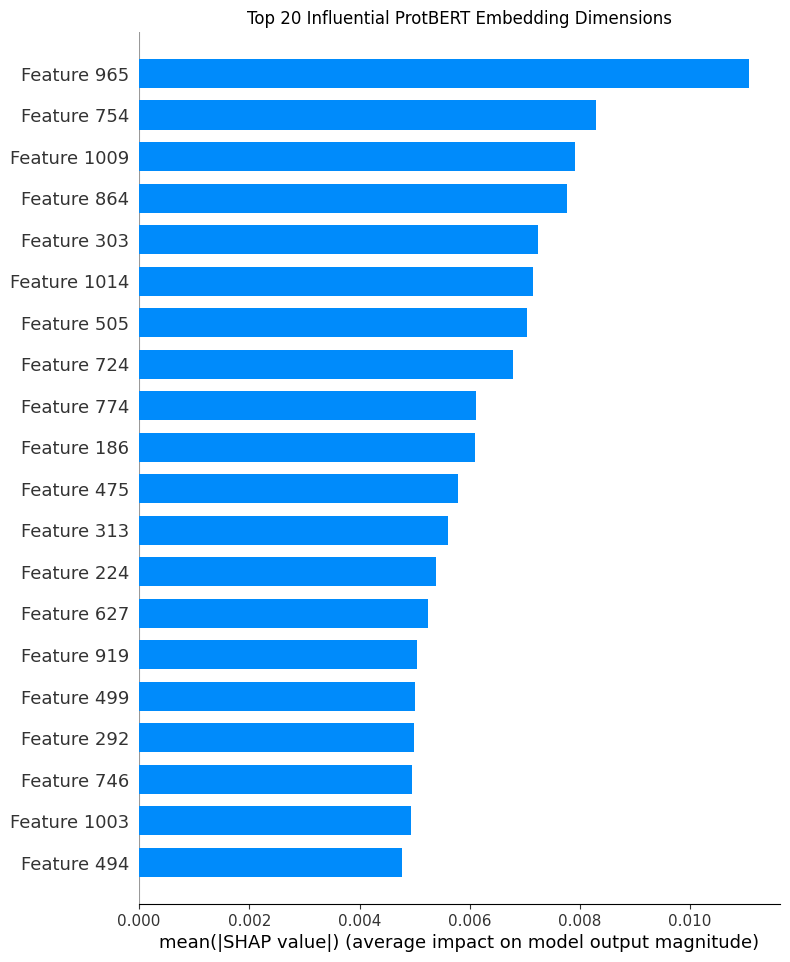

In [3]:
# Re-train a quick RF for demonstration (or load if saved)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

print("Computing SHAP values (this may take a moment)...")
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X)

# Handle different SHAP output formats (list of arrays or 3D array)
if isinstance(shap_values, list):
    # Older SHAP version: list of [neg, pos]
    sv = shap_values[1]
elif len(shap_values.shape) == 3:
    # Newer SHAP version: (samples, features, classes)
    sv = shap_values[:, :, 1]
else:
    # 2D array: (samples, features)
    sv = shap_values

# Summary Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(sv, X, plot_type="bar", max_display=20, show=False)
plt.title("Top 20 Influential ProtBERT Embedding Dimensions")
plt.savefig('../results/shap_summary.png', dpi=300, bbox_inches='tight')
plt.show()

## 3. Conclusions

- **UMAP Visualization:** Shows clear clustering of proteins based on their functional category, validating that ProtBERT embeddings capture high-level biological information.
- **SHAP Summary:** Identifies the specific latent dimensions that the model relies on most. While these dimensions (e.g., Feature 453) are abstract, they represent learned biochemical properties that distinguish enzymatic activity.